In [1]:
###################################################################################################
#
# Copyright (C) 2025 Analog Devices, Inc. All Rights Reserved.
#
# Analog Devices, Inc. Default Copyright Notice:
#
###################################################################################################

import os
import sys
import importlib

import numpy as np
import torch
from torch.utils import data

import matplotlib.patches as patches
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'models'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'losses'))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'metrics'))

from distiller import apputils
import parse_qat_yaml

import ai8x
from datasets import nilm
from losses.nilmmultitargetloss import NILMMultiTargetLoss
from metrics.nilm import CustomNILMRegressionMetrics



C:\Users\MTinaco\Dev\Algorithm\max7800x\ai8x-training\distiller\build\__editable__.distiller-0.4.0rc0-py3-none-any\distiller\summary_graph.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### Create test and train sets and visualize sample item/s

In [2]:
device = "cpu"
#CHANGE ME: Change below path to folder that contains or will contain dataset
#           (Data loader will create and use PascalVOC folder ubder this main root folder)
#           Below is an example where a path under Ubuntu root folder ('/'): /data2/ml/ 
#           is used for data files'
data_path = os.path.join('../', 'data')

class Args:
    def __init__(self, act_mode_8bit):
        self.act_mode_8bit = act_mode_8bit
        self.truncate_testset = False

simulate = False
args = Args(act_mode_8bit=simulate)


train_set, test_set = \
    nilm.ukdale_128_seq2point_get_datasets((data_path, args), load_train=True, load_test=True)
                        

In [3]:
trained_checkpoint_path = os.path.join("..", "..", "ai8x-synthesis", "trained", "ai85-nilm-seq2point-128-qat8-q.pth.tar")
mod = importlib.import_module("ai85net-nilm-seq2point-128")

In [4]:
start = 80000
stop = 90000
y_axis = train_set.input_array[start:stop]
x_axis = np.linspace(start, stop, stop-start)

In [5]:
plt.plot(x_axis, y_axis)

In [6]:
selected_idx = 82600

sample_item = test_set[selected_idx]
sample_input = sample_item[0].cpu().detach().numpy()

sample_input

array([[-1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -1.       , -1.       , -1.       , -1.       ,
        -1.       , -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9296875, -0.9296875,
        -0.9296875, -0.9296875, -0.9296875, -0.9

In [7]:
plt.plot(sample_input[0])

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Working with device:", device)



Working with device: cuda


In [9]:
train_batch_size = 256
test_dataloader = data.DataLoader(test_set, batch_size=train_batch_size, shuffle=False)

In [10]:
qat_yaml_file_used_in_training = os.path.join(os.path.dirname(os.getcwd()), 'policies', 'qat_policy_nilm.yaml')
qat_policy = parse_qat_yaml.parse(qat_yaml_file_used_in_training)

checkpoint = torch.load(trained_checkpoint_path)

ai8x.set_device(device=85, simulate=True, round_avg=False)

model = mod.AI85NILMSeq2Point128(num_classes=5, num_channels=1, dimensions=(128, 1), bias=True)

# Fuse the BN parameters into conv layers before Quantization Aware Training (QAT)
ai8x.fuse_bn_layers(model)

model = apputils.load_lean_checkpoint(model, trained_checkpoint_path, model_device=device)

ai8x.initiate_qat(model, qat_policy)
ai8x.update_model(model)

model = model.to(device)

Configuring device: MAX78000, simulate=True.


In [11]:
from tqdm import tqdm

In [ ]:
model.eval()


num_quantiles = 5
softmax = torch.nn.Softmax(dim=1)

preds = torch.empty(len(test_dataloader)*train_batch_size, 5)
targs = torch.empty(len(test_dataloader)*train_batch_size, 5)

with torch.no_grad():
    for idx, (inputs, target) in enumerate(tqdm(test_dataloader)):
        inputs = inputs.to(device)

        outputs = model(inputs)

        output_state = outputs[:,:2*5].reshape(train_batch_size, 2, -1)
        output_power = outputs[:,2*5:].reshape(train_batch_size, num_quantiles, -1)

        prob, pred_state = torch.max(softmax(output_state), 1)

        pred_power = (output_power + 127) / 255
        pred_power = torch.clip(pred_power, min=0, max=255)
        pred_power = pred_power[:,2]

        pred = pred_state * pred_power

        targ_power = ((target[1] + 1) / 2) * 255
        
        # targ = target[0] * targ_power
        # targ = targ_power
        targ = target[0]

        preds[idx*train_batch_size:(idx+1)*train_batch_size, :5] = pred
        targs[idx*train_batch_size:(idx+1)*train_batch_size, :5] = targ


 27%|██▋       | 501/1856 [00:49<03:02,  7.44it/s]

In [14]:
preds_array = preds.cpu().detach().numpy()
targs_array = targs.cpu().detach().numpy()

In [15]:
%matplotlib inline

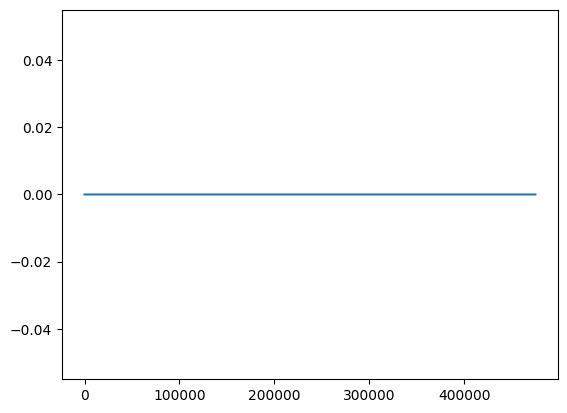

In [21]:
plt.plot(targs[:,4])
plt.show()